In [1]:
import pandas as pd
import numpy as np

np.random.seed(77)
n = 600

productos = {
    "Ventilador Mecánico":   {"categoria": "Equipo UCI",         "precio_base": 180000, "costo": 108000},
    "Monitor de Signos":     {"categoria": "Equipo UCI",         "precio_base": 45000,  "costo": 27000},
    "Bomba de Infusión":     {"categoria": "Medicación IV",      "precio_base": 28000,  "costo": 16800},
    "Desfibrilador":         {"categoria": "Emergencias",        "precio_base": 95000,  "costo": 57000},
    "Oxímetro Portátil":     {"categoria": "Diagnóstico",        "precio_base": 8500,   "costo": 5100},
    "Electrocardiógrafo":    {"categoria": "Diagnóstico",        "precio_base": 32000,  "costo": 19200},
    "Cama Hospitalaria":     {"categoria": "Mobiliario Clínico", "precio_base": 22000,  "costo": 13200},
    "Silla de Ruedas Elec.": {"categoria": "Rehabilitación",     "precio_base": 35000,  "costo": 21000},
}

hospitales = {
    "IMSS":              {"tipo": "Público",  "descuento_max": 0.20, "volumen": 0.30},
    "ISSSTE":            {"tipo": "Público",  "descuento_max": 0.18, "volumen": 0.15},
    "SEDESA":            {"tipo": "Público",  "descuento_max": 0.22, "volumen": 0.10},
    "Médica Sur":        {"tipo": "Privado",  "descuento_max": 0.10, "volumen": 0.15},
    "Hospital Ángeles":  {"tipo": "Privado",  "descuento_max": 0.08, "volumen": 0.15},
    "Christus Muguerza": {"tipo": "Privado",  "descuento_max": 0.12, "volumen": 0.10},
    "Star Médica":       {"tipo": "Privado",  "descuento_max": 0.09, "volumen": 0.05},
}

representantes = [f"Rep_{i:02d}" for i in range(1, 11)]
trimestres     = ["Q1", "Q2", "Q3", "Q4"]
regiones       = ["CDMX", "Guadalajara", "Monterrey", "Puebla", "Bajío"]

productos_lista  = list(productos.keys())
hospitales_lista = list(hospitales.keys())
probs_hosp       = [hospitales[h]["volumen"] for h in hospitales_lista]

productos_col  = np.random.choice(productos_lista, n)
hospitales_col = np.random.choice(hospitales_lista, n, p=probs_hosp)

df = pd.DataFrame({
    "transaction_id":  [f"TXN-{i:04d}" for i in range(1, n+1)],
    "trimestre":       np.random.choice(trimestres, n, p=[0.30, 0.25, 0.25, 0.20]),
    "region":          np.random.choice(regiones, n, p=[0.35, 0.25, 0.20, 0.12, 0.08]),
    "hospital":        hospitales_col,
    "tipo_hospital":   [hospitales[h]["tipo"] for h in hospitales_col],
    "producto":        productos_col,
    "categoria":       [productos[p]["categoria"] for p in productos_col],
    "representante":   np.random.choice(representantes, n),
    "unidades":        np.random.randint(1, 15, n),
    "precio_base":     [productos[p]["precio_base"] for p in productos_col],
    "costo_unitario":  [productos[p]["costo"] for p in productos_col],
    "descuento":       [round(np.random.uniform(0, hospitales[h]["descuento_max"]), 3)
                        for h in hospitales_col],
    "contrato_activo": np.random.choice([1, 0], n, p=[0.75, 0.25]),
    "dias_entrega":    np.random.randint(3, 45, n),
})

df["precio_final"]  = (df["precio_base"] * (1 - df["descuento"])).round(2)
df["venta_total"]   = (df["precio_final"] * df["unidades"]).round(2)
df["costo_total"]   = (df["costo_unitario"] * df["unidades"]).round(2)
df["margen_bruto"]  = (df["venta_total"] - df["costo_total"]).round(2)
df["margen_pct"]    = ((df["margen_bruto"] / df["venta_total"]) * 100).round(1)
df["comision_pct"]  = np.where(df["tipo_hospital"] == "Privado", 0.06,
                      np.where(df["margen_pct"] >= 40, 0.04, 0.025))
df["comision_mxn"]  = (df["venta_total"] * df["comision_pct"]).round(2)

In [2]:
display(df.info())
display(df.describe())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transaction_id   600 non-null    object 
 1   trimestre        600 non-null    object 
 2   region           600 non-null    object 
 3   hospital         600 non-null    object 
 4   tipo_hospital    600 non-null    object 
 5   producto         600 non-null    object 
 6   categoria        600 non-null    object 
 7   representante    600 non-null    object 
 8   unidades         600 non-null    int64  
 9   precio_base      600 non-null    int64  
 10  costo_unitario   600 non-null    int64  
 11  descuento        600 non-null    float64
 12  contrato_activo  600 non-null    int64  
 13  dias_entrega     600 non-null    int64  
 14  precio_final     600 non-null    float64
 15  venta_total      600 non-null    float64
 16  costo_total      600 non-null    int64  
 17  margen_bruto    

None

,unidades,precio_base,costo_unitario,descuento,contrato_activo,dias_entrega,precio_final,venta_total,costo_total,margen_bruto,margen_pct,comision_pct,comision_mxn
count,600.000000,600.000000,600.000000,600.000000,600.000,600.000000,600.000000,6.000000e+02,6.000000e+02,600.000000,600.000000,600.000000,600.000000
mean,7.421667,52531.666667,31519.000000,0.076137,0.740,23.358333,48608.777500,3.537118e+05,2.297590e+05,123952.820833,34.818833,0.039542,14448.717417
std,3.932723,49771.429112,29862.857467,0.054652,0.439,12.329773,46412.441933,4.150669e+05,2.688007e+05,148361.380191,4.022432,0.017219,20194.196525
min,1.000000,8500.000000,5100.000000,0.000000,0.000,3.000000,6902.000000,7.344000e+03,5.100000e+03,2244.000000,24.000000,0.025000,183.600000
25%,4.000000,22000.000000,13200.000000,0.033000,0.000,12.000000,21796.500000,9.526350e+04,6.600000e+04,34348.500000,32.000000,0.025000,3623.880000
50%,7.000000,32000.000000,19200.000000,0.061500,1.000,24.000000,30741.000000,2.274200e+05,1.470000e+05,75773.000000,36.050000,0.025000,7720.600000
75%,11.000000,45000.000000,27000.000000,0.117000,1.000,34.000000,43695.000000,3.802950e+05,2.496000e+05,138651.000000,38.000000,0.060000,16232.175000
max,14.000000,180000.000000,108000.000000,0.211000,1.000,44.000000,180000.000000,2.343600e+06,1.512000e+06,863460.000000,40.000000,0.060000,140616.000000


,transaction_id,trimestre,region,hospital,tipo_hospital,producto,categoria,representante,unidades,precio_base,...,descuento,contrato_activo,dias_entrega,precio_final,venta_total,costo_total,margen_bruto,margen_pct,comision_pct,comision_mxn
0,TXN-0001,Q3,Monterrey,Star Médica,Privado,Silla de Ruedas Elec.,Rehabilitación,Rep_10,2,35000,...,0.014,1,25,34510.0,69020.0,42000,27020.0,39.1,0.060,4141.20
1,TXN-0002,Q1,Monterrey,Médica Sur,Privado,Silla de Ruedas Elec.,Rehabilitación,Rep_03,7,35000,...,0.073,0,10,32445.0,227115.0,147000,80115.0,35.3,0.060,13626.90
2,TXN-0003,Q4,CDMX,Médica Sur,Privado,Oxímetro Portátil,Diagnóstico,Rep_05,9,8500,...,0.091,0,40,7726.5,69538.5,45900,23638.5,34.0,0.060,4172.31
3,TXN-0004,Q3,Monterrey,SEDESA,Público,Oxímetro Portátil,Diagnóstico,Rep_04,10,8500,...,0.021,1,13,8321.5,83215.0,51000,32215.0,38.7,0.025,2080.38
4,TXN-0005,Q4,Puebla,Hospital Ángeles,Privado,Desfibrilador,Emergencias,Rep_06,8,95000,...,0.062,1,17,89110.0,712880.0,456000,256880.0,36.0,0.060,42772.80


In [3]:
print(f"Total of null values by column:\n{df.isnull().sum()}")
print("-" * 40)
print(f"Total of duplicate rows: {df.duplicated().sum()}")

Total of null values by column:
transaction_id     0
trimestre          0
region             0
hospital           0
tipo_hospital      0
producto           0
categoria          0
representante      0
unidades           0
precio_base        0
costo_unitario     0
descuento          0
contrato_activo    0
dias_entrega       0
precio_final       0
venta_total        0
costo_total        0
margen_bruto       0
margen_pct         0
comision_pct       0
comision_mxn       0
dtype: int64
----------------------------------------
Total of duplicate rows: 0


In [4]:
# Execute Summary Statistics and Key Performance Indicators (KPIs)
total_revenues = df["venta_total"].sum()
total_costs = df["costo_total"].sum()
total_gross_margin = df["margen_bruto"].sum()
average_margin_pct = df["margen_pct"].mean()
total_commissions = df["comision_mxn"].sum()
total_transactions = len(df)
active_contracts = df["contrato_activo"].sum()
inactive_contracts = total_transactions - active_contracts
print(f"Total Revenues:     ${total_revenues:>15,.2f}")
print(f"Total Costs:        ${total_costs:>15,.2f}")
print(f"Total Gross Margin: ${total_gross_margin:>15,.2f}")
print(f"Average Margin %:   {average_margin_pct:>15.2f}")
print(f"Total Commissions:  ${total_commissions:>15,.2f}")
print(f"Total Transactions: {total_transactions:>15}")
print(f"Active Contracts:   {active_contracts:>15}")
print(f"Inactive Contracts: {inactive_contracts:>15}")

Total Revenues:     $ 212,227,092.50
Total Costs:        $ 137,855,400.00
Total Gross Margin: $  74,371,692.50
Average Margin %:             34.82
Total Commissions:  $   8,669,230.45
Total Transactions:             600
Active Contracts:               444
Inactive Contracts:             156


In [5]:
import sqlite3
conn = sqlite3.connect(":memory:")
df.to_sql("ventas", conn, index=False, if_exists="replace")
query1 = """
select  
    tipo_hospital,
    sum(venta_total) as total_revenues, 
    count(venta_total) as num_transactions,
    round(avg(margen_pct), 2) as average_margin,
    round(sum(comision_mxn), 2) as total_comission
from ventas 
group by tipo_hospital
order by total_revenues desc
"""
result1 = pd.read_sql_query(query1, conn)
display(result1)

,tipo_hospital,total_revenues,num_transactions,average_margin,total_comission
0,Público,116300217.5,352,33.12,2913617.95
1,Privado,95926875.0,248,37.23,5755612.50


In [6]:
query2 = """
select 
    categoria,
    producto,
    count(venta_total) as total_units,
    round(sum(venta_total), 2) as total_revenues,
    round(avg(margen_pct), 2) as average_margin,
    rank() over (order by avg(margen_pct) desc) as margin_rank
    
from ventas
group by categoria, producto
order by margin_rank
"""
result2 = pd.read_sql_query(query2, conn)
display(result2)

,categoria,producto,total_units,total_revenues,average_margin,margin_rank
0,Equipo UCI,Ventilador Mecánico,63,73966500.0,35.11,1
1,Mobiliario Clínico,Cama Hospitalaria,79,11432718.0,35.09,2
2,Emergencias,Desfibrilador,73,45982090.0,35.06,3
3,Diagnóstico,Oxímetro Portátil,78,4515242.5,35.05,4
4,Rehabilitación,Silla de Ruedas Elec.,77,17659320.0,34.79,5
5,Equipo UCI,Monitor de Signos,84,26412750.0,34.71,6
6,Medicación IV,Bomba de Infusión,76,14698152.0,34.40,7
7,Diagnóstico,Electrocardiógrafo,70,17560320.0,34.36,8


In [7]:
query3 = """
select 
    representante,
    trimestre,
    count(venta_total) as num_ventas,
    round(sum(venta_total), 2) as total_revenues,
    round(sum(comision_mxn), 2) as total_comission,
    rank() over (order by sum(comision_mxn) desc) as commission_rank
from ventas
WHERE trimestre = 'Q1'
group by representante
order by commission_rank
"""
result3 = pd.read_sql_query(query3, conn)
display(result3)

,representante,trimestre,num_ventas,total_revenues,total_comission,commission_rank
0,Rep_10,Q1,17,9262473.0,473336.09,1
1,Rep_01,Q1,21,9297331.5,419549.29,2
2,Rep_07,Q1,18,6506256.0,362264.62,3
3,Rep_09,Q1,19,8521989.0,345212.49,4
4,Rep_06,Q1,21,5183461.5,241651.18,5
5,Rep_02,Q1,18,5461694.5,208971.52,6
6,Rep_05,Q1,13,4352745.0,197630.81,7
7,Rep_03,Q1,12,3954110.0,185262.96,8
8,Rep_04,Q1,18,3819620.5,150273.42,9
9,Rep_08,Q1,16,4773877.0,149692.36,10


In [8]:
query4 = """
select
    hospital,
    tipo_hospital,
    contrato_activo,
    count(venta_total) as num_ventas,
    round(sum(venta_total), 2) as total_revenues
from ventas
where contrato_activo = 0
group by hospital, tipo_hospital
order by total_revenues desc
"""
result4 = pd.read_sql_query(query4, conn)
display(result4)


,hospital,tipo_hospital,contrato_activo,num_ventas,total_revenues
0,IMSS,Público,0,42,13676538.0
1,ISSSTE,Público,0,28,13667541.0
2,Hospital Ángeles,Privado,0,22,8454297.5
3,Médica Sur,Privado,0,23,6499098.0
4,SEDESA,Público,0,17,5653196.5
5,Star Médica,Privado,0,12,3423415.0
6,Christus Muguerza,Privado,0,12,2891093.0


In [9]:
query5 = """
select
    region,
    trimestre,
    count(venta_total) as num_ventas,
    round(sum(venta_total), 2) as total_revenues,
    round(avg(margen_pct), 2) as average_margin
from ventas
group by region, trimestre
order by region
"""
result5 = pd.read_sql_query(query5, conn)
display(result5)


,region,trimestre,num_ventas,total_revenues,average_margin
0,Bajío,Q1,15,4927365.0,35.07
1,Bajío,Q2,10,1946402.5,34.32
2,Bajío,Q3,10,2189361.0,35.45
3,Bajío,Q4,10,2842231.5,36.40
4,CDMX,Q1,64,20405198.0,34.50
5,CDMX,Q2,46,20937636.5,34.84
6,CDMX,Q3,58,20912837.5,34.53
7,CDMX,Q4,43,14197052.5,34.52
8,Guadalajara,Q1,39,11802479.5,35.77
9,Guadalajara,Q2,31,7861266.5,34.49


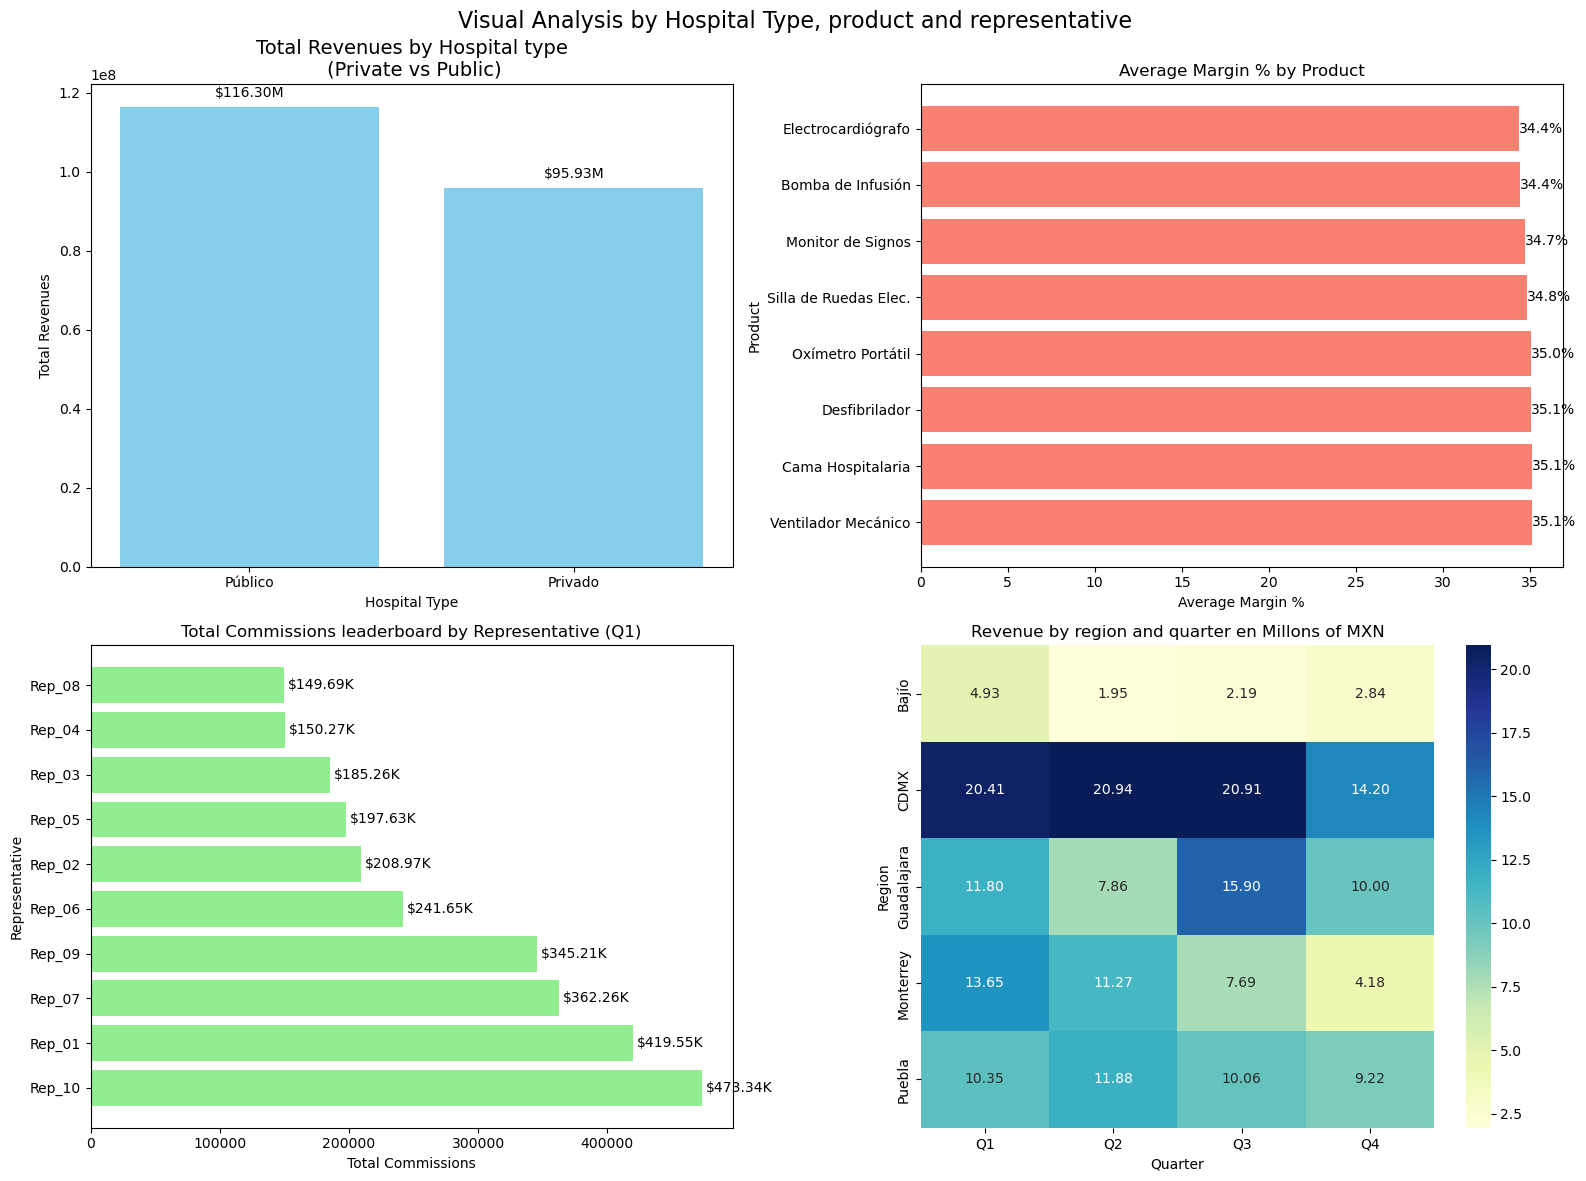

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Visual Analysis by Hospital Type, product and representative", fontsize=16)

axes[0, 0].set_title("Total Revenues by Hospital type\n (Private vs Public)", fontsize=14)
axes[0, 0].bar(result1["tipo_hospital"], result1["total_revenues"], color="skyblue")
axes[0, 0].set_xlabel("Hospital Type")
axes[0, 0].set_ylabel("Total Revenues")
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container,
                         labels=[f"${v/1e6:.2f}M" for v in result1["total_revenues"]]
                         ,label_type="edge", padding=5)

axes[0, 1].set_title("Average Margin % by Product")
axes[0,1].barh(result2["producto"], result2["average_margin"], color="salmon")
axes[0, 1].set_xlabel("Average Margin %")
axes[0, 1].set_ylabel("Product")
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt="%.1f%%", label_type="edge")

axes[1, 0].set_title("Total Commissions leaderboard by Representative (Q1)")
axes[1,0].barh(result3["representante"], result3["total_comission"], color="lightgreen")
axes[1, 0].set_xlabel("Total Commissions")
axes[1, 0].set_ylabel("Representative")
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container,
                         labels=[f"${v/1e3:.2f}K" for v in result3["total_comission"]],
                         label_type="edge",
                          padding=3)



axes[1, 1].set_title("Revenue by region and quarter en Millons of MXN")
sns.heatmap(result5.pivot(index="region", columns="trimestre", values="total_revenues")/1e6, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1, 1])
axes[1, 1].set_xlabel("Quarter")
axes[1, 1].set_ylabel("Region") 
 

plt.tight_layout()
plt.show()




In [11]:
import io
from openpyxl.drawing.image import Image as XLimage


buffer = io.BytesIO()
fig.savefig(buffer, format="png",dpi=300)
buffer.seek(0)
plt.close(fig)

with pd.ExcelWriter("Reporte_MedSupply_México.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Datos_Completos", index=False)
    result1.to_excel(writer, sheet_name="Resumen_Hospitales", index=False)
    result2.to_excel(writer, sheet_name="Resumen_Productos", index=False)
    result3.to_excel(writer, sheet_name="Resumen_Representantes_Q1", index=False)
    result4.to_excel(writer, sheet_name="Contratos_Inactivos", index=False)
    result5.to_excel(writer, sheet_name="Resumen_Region_Trimestre", index=False)

    workbook = writer.book
    worksheet = workbook.create_sheet("Dashboard")
    img = XLimage(buffer)
    img.width, img.height = 1200, 900
    worksheet.add_image(img, "A1")

print("Reporte generado exitosamente: 'Reporte_MedSupply_México.xlsx'")


Reporte generado exitosamente: 'Reporte_MedSupply_México.xlsx'
